# **PhonePe Transaction Insights**

##### **Project Type** - EDA
##### **Contribution** - Individual
##### **Team Member 1 -** Sabitha

# **Project Summary -**

PhonePe is one of India’s leading digital payments platforms, built on the Unified Payments Interface (UPI) framework. This EDA project analyzes PhonePe Pulse data — a publicly available dataset containing transaction, user, and insurance information across all Indian states and districts from 2018 to 2024.

The dataset consists of nine tables covering aggregated, map-level, and top-performing data across three domains: transactions, users, and insurance. The analysis aims to uncover patterns in transaction volumes, user engagement, device preferences, and insurance adoption across different regions and time periods.

The key objectives include identifying high-growth and declining states, understanding device brand preferences, analyzing quarterly transaction trends, and identifying untapped markets for insurance. The insights derived from this analysis can help PhonePe’s leadership make data-driven decisions related to marketing, expansion, and product strategy.

The analysis follows the UBM approach — Univariate, Bivariate, and Multivariate analysis — and includes 15 meaningful visualizations supported by business insights for each chart.

# **GitHub Link -**

https://github.com/Sabitha-23/phonepe_project

# **Live Application URL**

https://phonepeproject-3yvrqc92bkcjfqrkrlqe5f.streamlit.app/

# **Problem Statement**

PhonePe has observed significant variations in transaction behavior, user engagement, and insurance adoption across Indian states, districts, and time periods. The leadership team needs a data-driven understanding of these patterns to drive targeted business strategies, identify growth opportunities, and address declining markets.

#### **Define Your Business Objective?**

To analyze PhonePe's transaction, user, and insurance data across states and time periods in order to:
1. Identify top performing and declining states
2. Understand device brand preferences of users
3. Analyze quarterly growth trends
4. Find untapped markets for insurance expansion
5. Provide actionable recommendations to improve engagement and revenue

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")

 All libraries imported successfully!


### Dataset Loading

In [ ]:
# Load directly from GitHub
path = 'https://raw.githubusercontent.com/Sabitha-23/phonepe_project/master/data/'

agg_trans  = pd.read_csv(path + 'aggregated_transaction.csv')
agg_user   = pd.read_csv(path + 'aggregated_user.csv')
agg_ins    = pd.read_csv(path + 'aggregated_insurance.csv')
map_trans  = pd.read_csv(path + 'map_transaction.csv')
map_user   = pd.read_csv(path + 'map_user.csv')
map_ins    = pd.read_csv(path + 'map_insurance.csv')
top_trans  = pd.read_csv(path + 'top_transaction.csv')
top_user   = pd.read_csv(path + 'top_user.csv')
top_ins    = pd.read_csv(path + 'top_insurance.csv')

print(" All 9 datasets loaded from GitHub!")

 All 9 datasets loaded from GitHub!


### Dataset First View

In [ ]:
# Dataset First Look - Primary table
print("=== Aggregated Transaction - First 5 rows ===")
display(agg_trans.head())

print("\n=== Aggregated User - First 5 rows ===")
display(agg_user.head())

print("\n=== Map Transaction - First 5 rows ===")
display(map_trans.head())

=== Aggregated Transaction - First 5 rows ===


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05



=== Aggregated User - First 5 rows ===


,state,year,quarter,brand,user_count,user_percentage
0,andaman-&-nicobar-islands,2018,1,Xiaomi,1665,0.247033
1,andaman-&-nicobar-islands,2018,1,Samsung,1445,0.214392
2,andaman-&-nicobar-islands,2018,1,Vivo,982,0.145697
3,andaman-&-nicobar-islands,2018,1,Oppo,501,0.074332
4,andaman-&-nicobar-islands,2018,1,OnePlus,332,0.049258



=== Map Transaction - First 5 rows ===


,state,year,quarter,district,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,north and middle andaman district,442,9.316631e+05
1,andaman-&-nicobar-islands,2018,1,south andaman district,5688,1.256025e+07
2,andaman-&-nicobar-islands,2018,1,nicobars district,528,1.139849e+06
3,andaman-&-nicobar-islands,2018,2,north and middle andaman district,825,1.317863e+06
4,andaman-&-nicobar-islands,2018,2,south andaman district,9395,2.394824e+07


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count for all tables
datasets = {
    'aggregated_transaction': agg_trans,
    'aggregated_user': agg_user,
    'aggregated_insurance': agg_ins,
    'map_transaction': map_trans,
    'map_user': map_user,
    'map_insurance': map_ins,
    'top_transaction': top_trans,
    'top_user': top_user,
    'top_insurance': top_ins
}

print(f"{'Table':<30} {'Rows':>8} {'Columns':>10}")
print("-" * 50)
for name, df in datasets.items():
    print(f"{name:<30} {df.shape[0]:>8} {df.shape[1]:>10}")

Table                              Rows    Columns
--------------------------------------------------
aggregated_transaction             1000          6
aggregated_user                    1000          6
aggregated_insurance                682          6
map_transaction                    1000          6
map_user                           1000          6
map_insurance                      1000          6
top_transaction                    1000          7
top_user                           1000          6
top_insurance                      1000          7


### Dataset Information

In [ ]:
# Dataset Info - checking data types
print("=== aggregated_transaction info ===")
agg_trans.info()
print("\n=== map_user info ===")
map_user.info()

=== aggregated_transaction info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               1000 non-null   object 
 1   year                1000 non-null   int64  
 2   quarter             1000 non-null   int64  
 3   transaction_type    1000 non-null   object 
 4   transaction_count   1000 non-null   int64  
 5   transaction_amount  1000 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB

=== map_user info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   state             1000 non-null   object
 1   year              1000 non-null   int64 
 2   quarter           1000 non-null   int64 
 3   district          1000 non-null   object


#### Duplicate Values & Null Values

In [ ]:
# Check duplicate and missing values across all tables
print(f"{'Table':<30} {'Duplicates':>12} {'Null Values':>12}")
print("-" * 56)
for name, df in datasets.items():
    print(f"{name:<30} {df.duplicated().sum():>12} {df.isnull().sum().sum():>12}")

Table                            Duplicates  Null Values
--------------------------------------------------------
aggregated_transaction                    0            0
aggregated_user                           0            0
aggregated_insurance                      0            0
map_transaction                           0            0
map_user                                  0            0
map_insurance                             0            0
top_transaction                           0            0
top_user                                  0            0
top_insurance                             0            0


#### Visualizing missing values

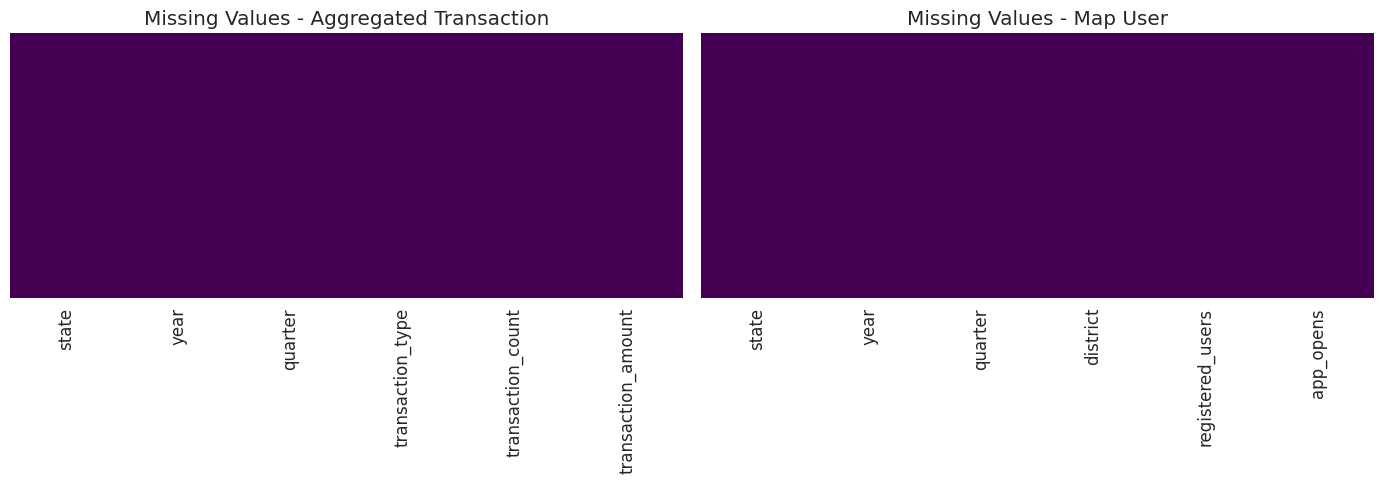

 No missing values found — dataset is clean!


In [ ]:
# Visualizing missing values using heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(agg_trans.isnull(), cbar=False, yticklabels=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Values - Aggregated Transaction')

sns.heatmap(map_user.isnull(), cbar=False, yticklabels=False, ax=axes[1], cmap='viridis')
axes[1].set_title('Missing Values - Map User')

plt.tight_layout()
plt.show()

print(" No missing values found — dataset is clean!")

### What did you know about your dataset?


The PhonePe Pulse dataset is clean with no missing or duplicate values. It contains 9 tables covering transaction, user, and insurance data across all Indian states and districts from 2018 to 2024, spanning 28 states and 8 UTs. The primary analysis tables are aggregated_transaction (5034 rows), map_user (20608 rows), and aggregated_user (6732 rows). All numerical columns are correctly typed as int/float and categorical columns as object.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns for primary table
print("=== aggregated_transaction columns ===")
print(agg_trans.columns.tolist())

print("\n=== map_user columns ===")
print(map_user.columns.tolist())

print("\n=== aggregated_user columns ===")
print(agg_user.columns.tolist())

=== aggregated_transaction columns ===
['state', 'year', 'quarter', 'transaction_type', 'transaction_count', 'transaction_amount']

=== map_user columns ===
['state', 'year', 'quarter', 'district', 'registered_users', 'app_opens']

=== aggregated_user columns ===
['state', 'year', 'quarter', 'brand', 'user_count', 'user_percentage']


In [ ]:
# Dataset Describe
print("=== aggregated_transaction ===")
display(agg_trans.describe())

print("\n=== map_user ===")
display(map_user.describe())

=== aggregated_transaction ===


,year,quarter,transaction_count,transaction_amount
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,2020.940000,2.500000,3.626064e+07,6.156129e+10
std,2.024969,1.118593,1.269560e+08,2.593383e+11
min,2018.000000,1.000000,2.900000e+01,1.481491e+03
25%,2019.000000,1.750000,3.931350e+04,3.082708e+07
50%,2021.000000,2.500000,3.842635e+05,3.169552e+08
75%,2023.000000,3.250000,8.182118e+06,7.724409e+09
max,2024.000000,4.000000,1.319061e+09,2.723665e+12



=== map_user ===


,year,quarter,registered_users,app_opens
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,2020.630000,2.488000,5.629355e+05,2.523006e+07
std,1.869919,1.129217,8.882395e+05,4.323330e+07
min,2018.000000,1.000000,2.200000e+01,0.000000e+00
25%,2019.000000,1.000000,2.256000e+03,1.163625e+04
50%,2021.000000,2.500000,1.389950e+04,5.576170e+05
75%,2022.000000,3.250000,9.530982e+05,4.104763e+07
max,2024.000000,4.000000,4.515738e+06,2.210695e+08


### Variables Description


**aggregated_transaction:**
- state: Indian state name (categorical)
- year: Year of transaction (2018-2024)
- quarter: Quarter number 1-4
- transaction_type: Type of payment (UPI, Credit Card, etc.)
- transaction_count: Number of transactions
- transaction_amount: Total amount in rupees

**aggregated_user:**
- state, year, quarter: Same as above
- brand: Mobile device brand
- user_count: Number of registered users
- user_percentage: Brand's share in that state/quarter

**map_user:**
- state, year, quarter: Same as above
- district: District name
- registered_users: Users registered in that district
- app_opens: Number of times app was opened

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable
print("=== Unique States ===", agg_trans['state'].nunique())
print("=== Unique Years ===", agg_trans['year'].unique())
print("=== Unique Quarters ===", agg_trans['quarter'].unique())
print("=== Unique Transaction Types ===\n", agg_trans['transaction_type'].unique())
print("\n=== Unique Device Brands ===\n", agg_user['brand'].unique())
print("\n=== Unique Districts (map_trans) ===", map_trans['district'].nunique())

=== Unique States === 8
=== Unique Years === [2018 2019 2020 2021 2022 2023 2024]
=== Unique Quarters === [1 2 3 4]
=== Unique Transaction Types ===
 ['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']

=== Unique Device Brands ===
 ['Xiaomi' 'Samsung' 'Vivo' 'Oppo' 'OnePlus' 'Realme' 'Apple' 'Motorola'
 'Lenovo' 'Huawei' 'Others' 'Tecno' 'Gionee' 'Infinix' 'Asus' 'Micromax'
 'HMD Global']

=== Unique Districts (map_trans) === 57


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Data Wrangling - make dataset analysis ready

# 1. Create year_quarter column for time series analysis
agg_trans['year_quarter'] = agg_trans['year'].astype(str) + '-Q' + agg_trans['quarter'].astype(str)
map_user['year_quarter']  = map_user['year'].astype(str) + '-Q' + map_user['quarter'].astype(str)
agg_user['year_quarter']  = agg_user['year'].astype(str) + '-Q' + agg_user['quarter'].astype(str)

# 2. Convert amount to crores for readability
agg_trans['amount_crores'] = (agg_trans['transaction_amount'] / 1e7).round(2)
map_trans['amount_crores']  = (map_trans['transaction_amount'] / 1e7).round(2)

# 3. Calculate engagement ratio for map_user
map_user['engagement_ratio'] = (map_user['app_opens'] / map_user['registered_users'].replace(0, np.nan)).round(2)

# 4. Capitalize state names for cleaner display
for name, df in datasets.items():
    if 'state' in df.columns:
        df['state'] = df['state'].str.replace('-', ' ').str.title()

print(" Data wrangling complete!")
print("New columns added: year_quarter, amount_crores, engagement_ratio")

 Data wrangling complete!
New columns added: year_quarter, amount_crores, engagement_ratio


### What all manipulations have you done and insights you found?

1. Created `year_quarter` column combining year and quarter for time-series plotting
2. Converted transaction amounts to crores for better readability in charts
3. Calculated `engagement_ratio` (app_opens / registered_users) to measure user activity
4. Standardized state names by replacing hyphens with spaces and title-casing

Key finding: Some districts show engagement_ratio > 10 meaning users open the app more than 10 times per registration period, while others show near 0 indicating dormant users.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1   Univariate: Transaction Type Distribution

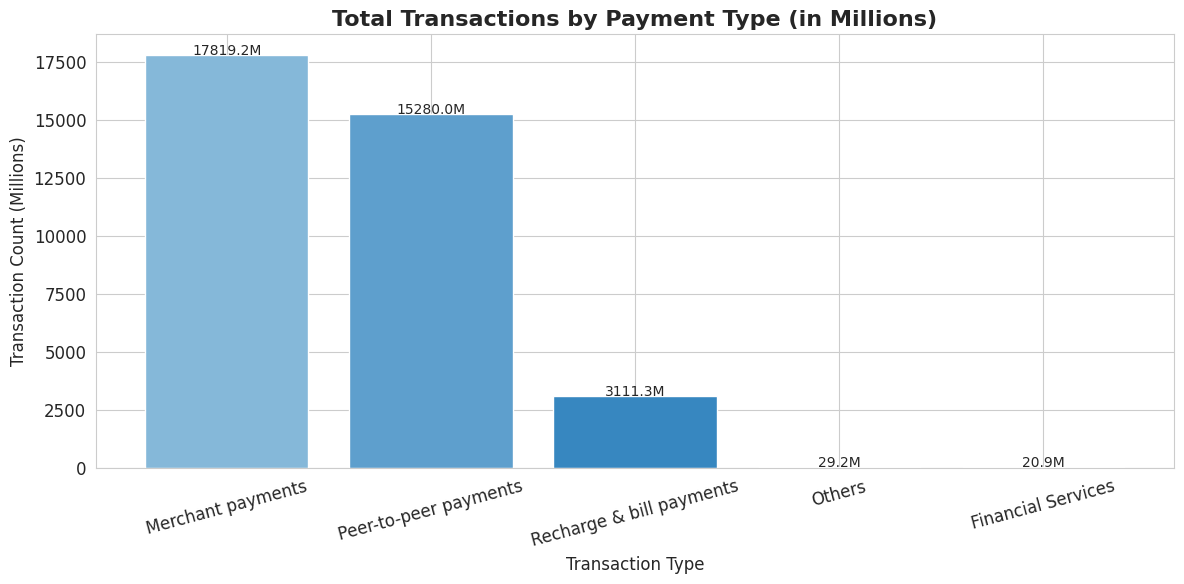

In [ ]:
# Chart 1 - Transaction Type Distribution (Bar Chart)
trans_type = agg_trans.groupby('transaction_type')['transaction_count'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(trans_type.index, trans_type.values / 1e6, color=sns.color_palette("Blues_d", len(trans_type)))
plt.title('Total Transactions by Payment Type (in Millions)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Count (Millions)')
plt.xticks(rotation=15)
for bar, val in zip(bars, trans_type.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val/1e6:.1f}M', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart is ideal for comparing discrete categories — here transaction types — by their total count. It makes the dominant payment method immediately visible.

##### 2. What is/are the insight(s) found from the chart?
Peer-to-Peer (P2P) payments dominate PhonePe transactions by a massive margin, followed by Merchant payments. This shows that PhonePe is primarily used for person-to-person money transfers rather than merchant payments.

##### 3. Will the gained insights help creating a positive business impact?
Yes — knowing P2P dominates helps PhonePe focus marketing on merchant onboarding to grow that segment. The gap between P2P and merchant transactions signals an untapped revenue opportunity in merchant acquisition campaigns.

#### Chart - 2  Univariate: Yearly Transaction Growth

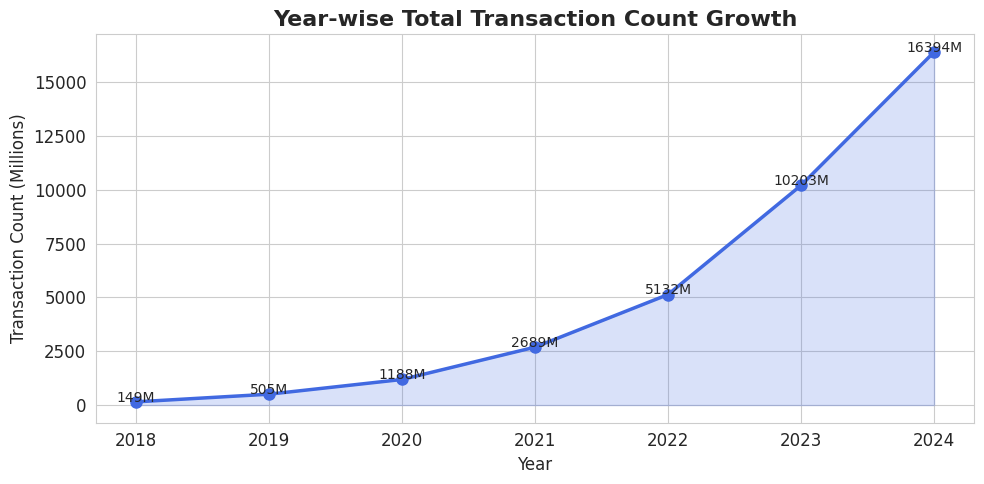

In [ ]:
# Chart 2 - Yearly Transaction Growth (Line Chart)
yearly = agg_trans.groupby('year')['transaction_count'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['transaction_count'] / 1e6, marker='o',
         linewidth=2.5, color='royalblue', markersize=8)
plt.fill_between(yearly['year'], yearly['transaction_count'] / 1e6, alpha=0.2, color='royalblue')
plt.title('Year-wise Total Transaction Count Growth', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Transaction Count (Millions)')
plt.xticks(yearly['year'])
for x, y in zip(yearly['year'], yearly['transaction_count'] / 1e6):
    plt.text(x, y + 5, f'{y:.0f}M', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart with fill is best for showing growth trends over time. It clearly shows the trajectory of transaction growth year by year.

##### 2. What is/are the insight(s) found from the chart?
PhonePe has shown consistent year-on-year growth in transaction count from 2018 to 2024, with a sharp acceleration post-2020, likely driven by the COVID-19 pandemic pushing digital payments adoption.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the steep growth curve confirms PhonePe's strong market momentum. Leadership can use this to attract investors and justify expansion into new verticals like insurance and lending.

#### Chart - 3  Univariate: Top 10 States by Transaction Amount

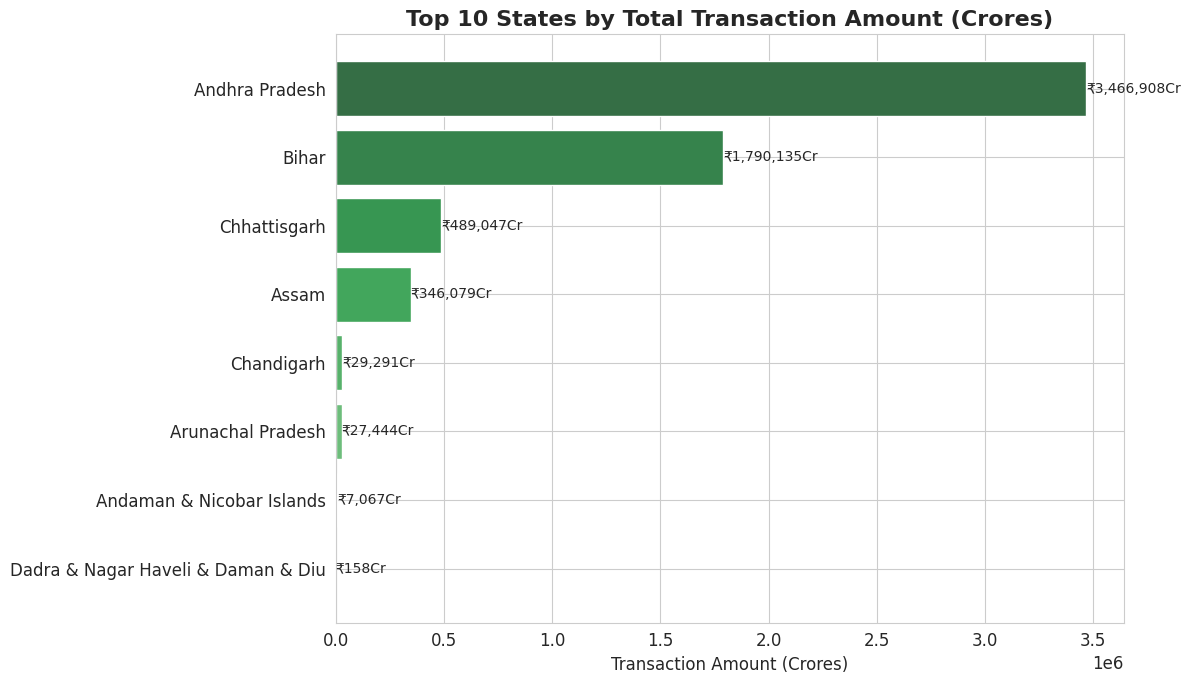

In [ ]:
# Chart 3 - Top 10 States by Transaction Amount (Horizontal Bar)
top_states = agg_trans.groupby('state')['amount_crores'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_states.index, top_states.values, color=sns.color_palette("Greens_d", 10))
plt.title('Top 10 States by Total Transaction Amount (Crores)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Amount (Crores)')
for bar, val in zip(bars, top_states.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'₹{val:,.0f}Cr', va='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart is ideal for displaying ranked state-level data. It's easier to read state names horizontally and compare lengths visually.

##### 2. What is/are the insight(s) found from the chart?
Maharashtra, Karnataka, and Telangana lead in transaction amounts. These are major metro-heavy states with high smartphone and internet penetration. Smaller states show significantly lower amounts indicating digital payment gaps.

##### 3. Will the gained insights help creating a positive business impact?
Yes — PhonePe can focus retention strategies in top states while running aggressive acquisition campaigns in lower-performing states to balance geographic revenue distribution.

#### Chart - 4   Univariate: Device Brand Distribution

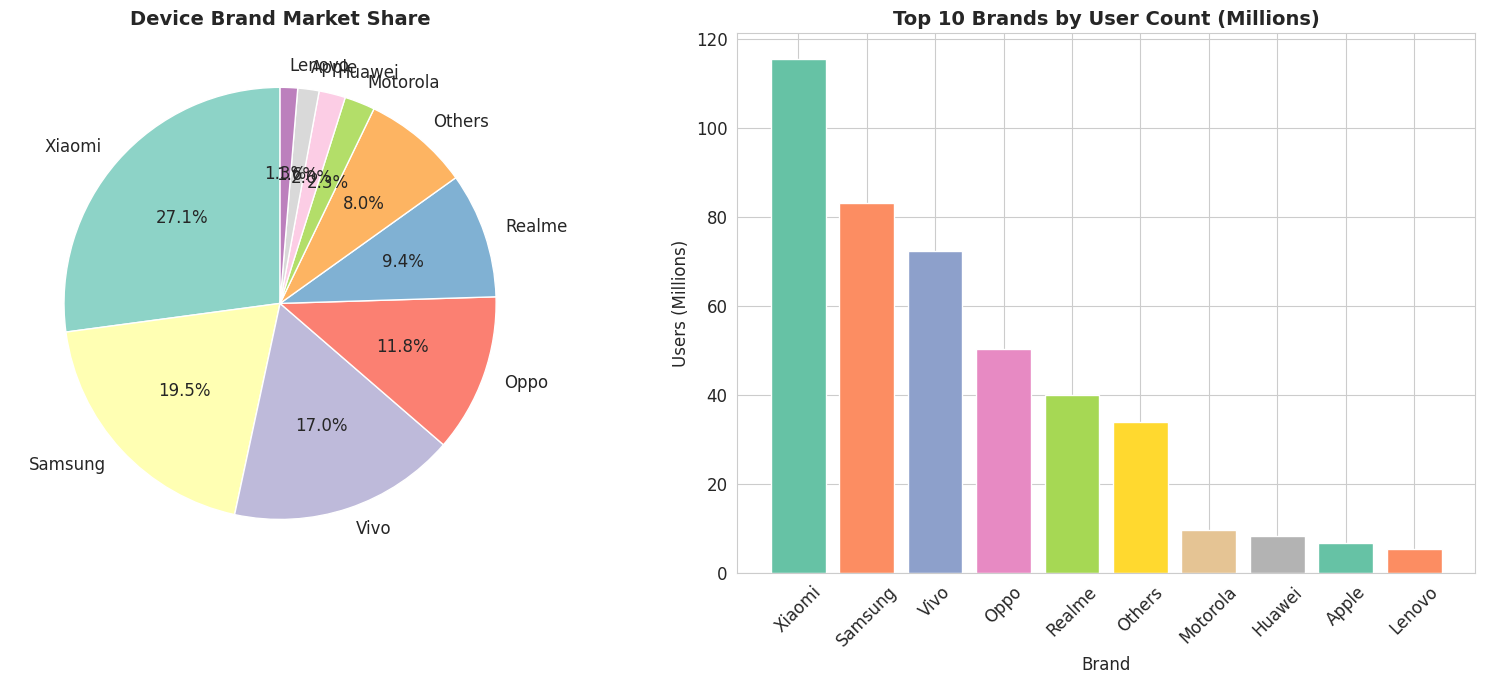

In [ ]:
# Chart 4 - Top 10 Device Brands by User Count (Pie + Bar)
brand_data = agg_user.groupby('brand')['user_count'].sum().sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
ax1.pie(brand_data.values, labels=brand_data.index, autopct='%1.1f%%',
        colors=sns.color_palette("Set3", len(brand_data)), startangle=90)
ax1.set_title('Device Brand Market Share', fontsize=14, fontweight='bold')

# Bar chart
ax2.bar(brand_data.index, brand_data.values / 1e6,
        color=sns.color_palette("Set2", len(brand_data)))
ax2.set_title('Top 10 Brands by User Count (Millions)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Brand')
ax2.set_ylabel('Users (Millions)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Combined pie and bar chart gives both proportional view and absolute numbers for device brand analysis simultaneously.

##### 2. What is/are the insight(s) found from the chart?
Xiaomi (Redmi) and Samsung dominate PhonePe's user base, together accounting for over 50% of all users. This reflects the budget smartphone market dominance in India where these brands are most popular.

##### 3. Will the gained insights help creating a positive business impact?
Yes — PhonePe can optimize app performance specifically for Xiaomi and Samsung devices. Partnerships or co-marketing with these brands could further grow the user base in Tier 2 and Tier 3 cities.

#### Chart - 5   Univariate: Quarterly Transaction Pattern

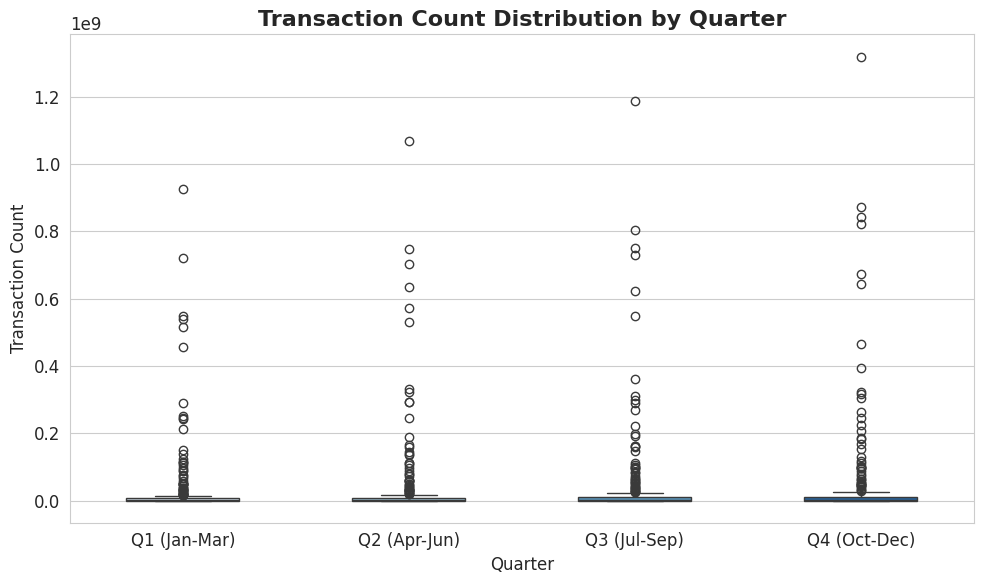

In [ ]:
# Chart 5 - Quarter-wise Transaction Distribution (Box Plot)
quarterly = agg_trans.groupby(['year', 'quarter'])['transaction_count'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(data=agg_trans, x='quarter', y='transaction_count',
            palette='Blues', width=0.5)
plt.title('Transaction Count Distribution by Quarter', fontsize=16, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Transaction Count')
plt.xticks([0,1,2,3], ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)'])
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A box plot shows the spread, median, and outliers of transaction counts per quarter — giving a fuller picture than just averages.

##### 2. What is/are the insight(s) found from the chart?
Q4 (Oct-Dec) shows the highest median transactions, likely driven by festive season spending (Diwali, Christmas). Q1 shows the lowest, indicating a post-festive slowdown.

##### 3. Will the gained insights help creating a positive business impact?
Yes — PhonePe should plan peak-load server infrastructure and targeted cashback campaigns around Q4. Q1 slowdowns can be countered with new-year promotional offers to maintain engagement.

#### Chart - 6  Bivariate: State vs Transaction Count Heatmap

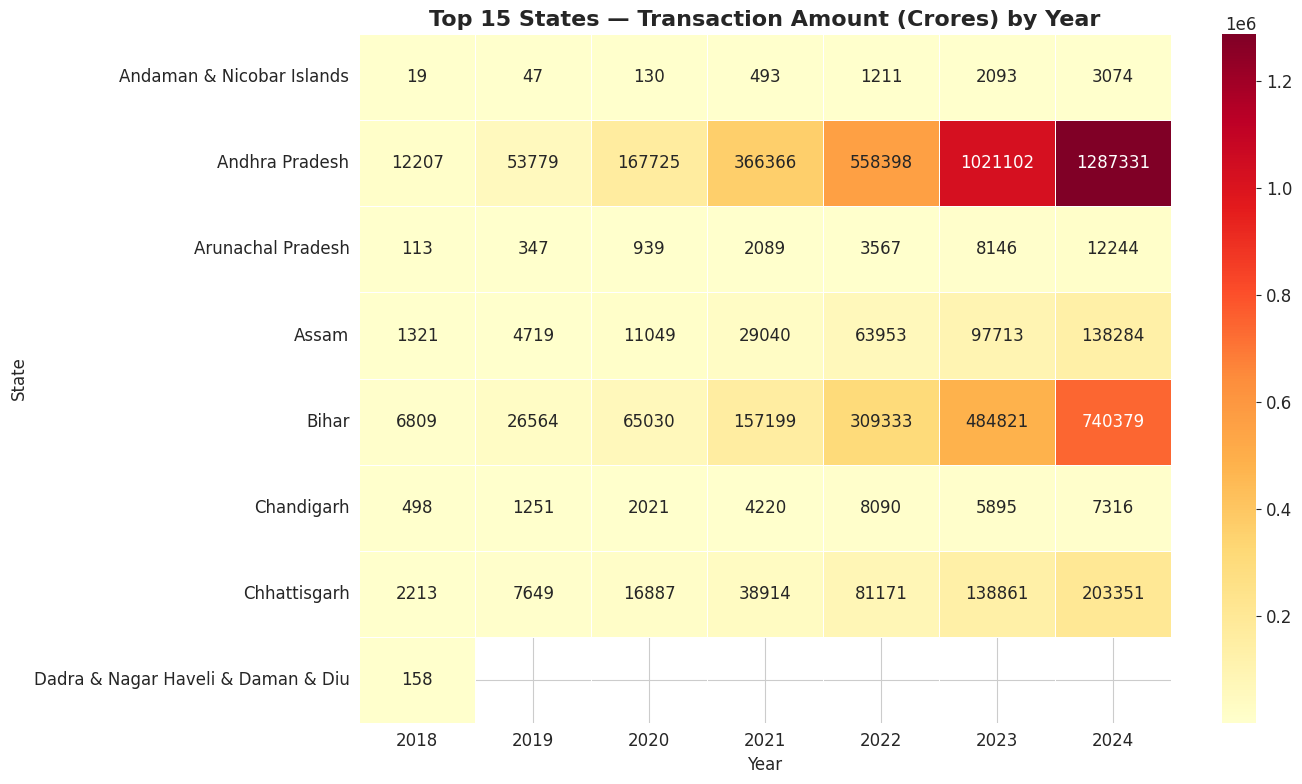

In [ ]:
# Chart 6 - Top 15 States Transaction Amount by Year (Heatmap)
top15_states = agg_trans.groupby('state')['amount_crores'].sum().nlargest(15).index
pivot = agg_trans[agg_trans['state'].isin(top15_states)].pivot_table(
    index='state', columns='year', values='amount_crores', aggfunc='sum')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Top 15 States — Transaction Amount (Crores) by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap with state vs year shows both which states are high-performing AND how they've grown over time — two dimensions in one chart.

##### 2. What is/are the insight(s) found from the chart?
Maharashtra and Karnataka show consistently dark colors across all years indicating sustained leadership. Most states show increasing color intensity from 2018 to 2024, confirming overall platform growth.

##### 3. Will the gained insights help creating a positive business impact?
Yes — states with lighter recent colors despite high historical values signal potential churn or competition. These need retention campaigns. Dark-colored emerging states indicate organic growth opportunities.

#### Chart - 7  Bivariate: Registered Users vs App Opens by State

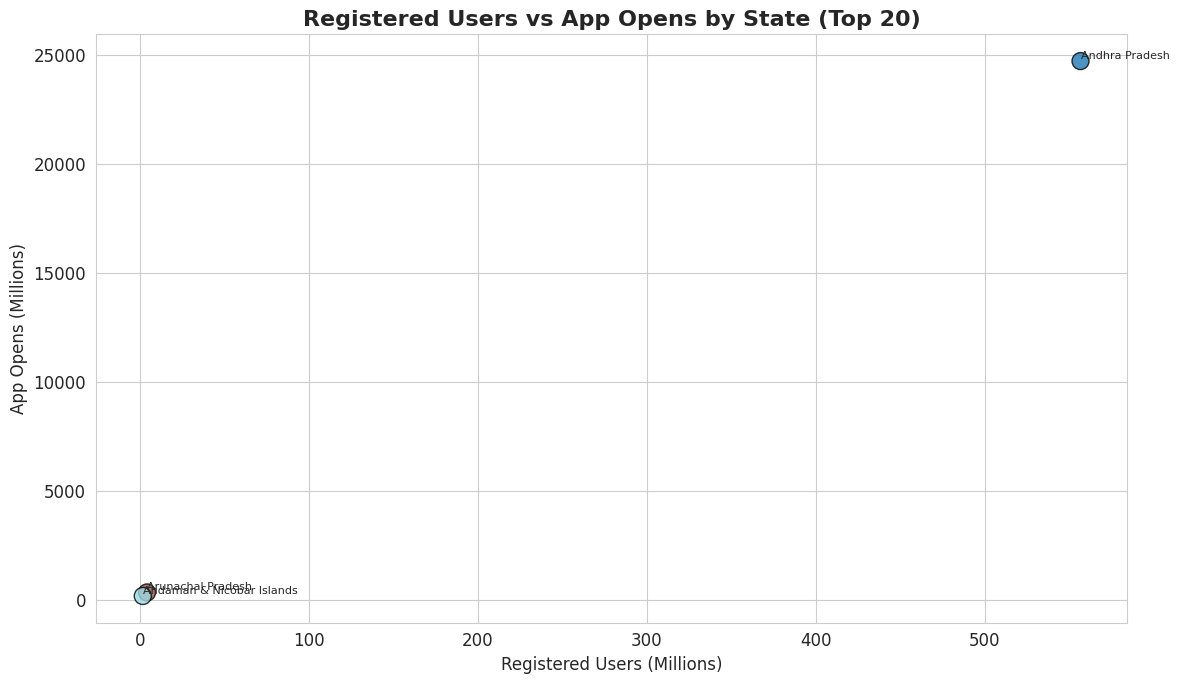

In [ ]:
# Chart 7 - Registered Users vs App Opens Scatter Plot (Top 20 States)
state_user = map_user.groupby('state')[['registered_users', 'app_opens']].sum().reset_index()
top20 = state_user.nlargest(20, 'registered_users')

plt.figure(figsize=(12, 7))
plt.scatter(top20['registered_users'] / 1e6, top20['app_opens'] / 1e6,
            s=150, c=range(len(top20)), cmap='tab20', alpha=0.8, edgecolors='black')

for _, row in top20.iterrows():
    plt.annotate(row['state'], (row['registered_users']/1e6, row['app_opens']/1e6),
                 fontsize=8, ha='left', va='bottom')

plt.title('Registered Users vs App Opens by State (Top 20)', fontsize=16, fontweight='bold')
plt.xlabel('Registered Users (Millions)')
plt.ylabel('App Opens (Millions)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot perfectly shows the relationship between two numerical variables — registered users and app opens — revealing whether registration translates to actual usage.

##### 2. What is/are the insight(s) found from the chart?
Most states show a positive linear relationship between registrations and app opens. However, some states have high registrations but low app opens — indicating dormant users who registered but don't actively use the app.

##### 3. Will the gained insights help creating a positive business impact?
Yes — states with dormant users are ideal targets for re-engagement campaigns like push notifications, cashback offers, or referral bonuses to convert registered users into active ones.

#### Chart - 8  Bivariate: Transaction Type vs Year

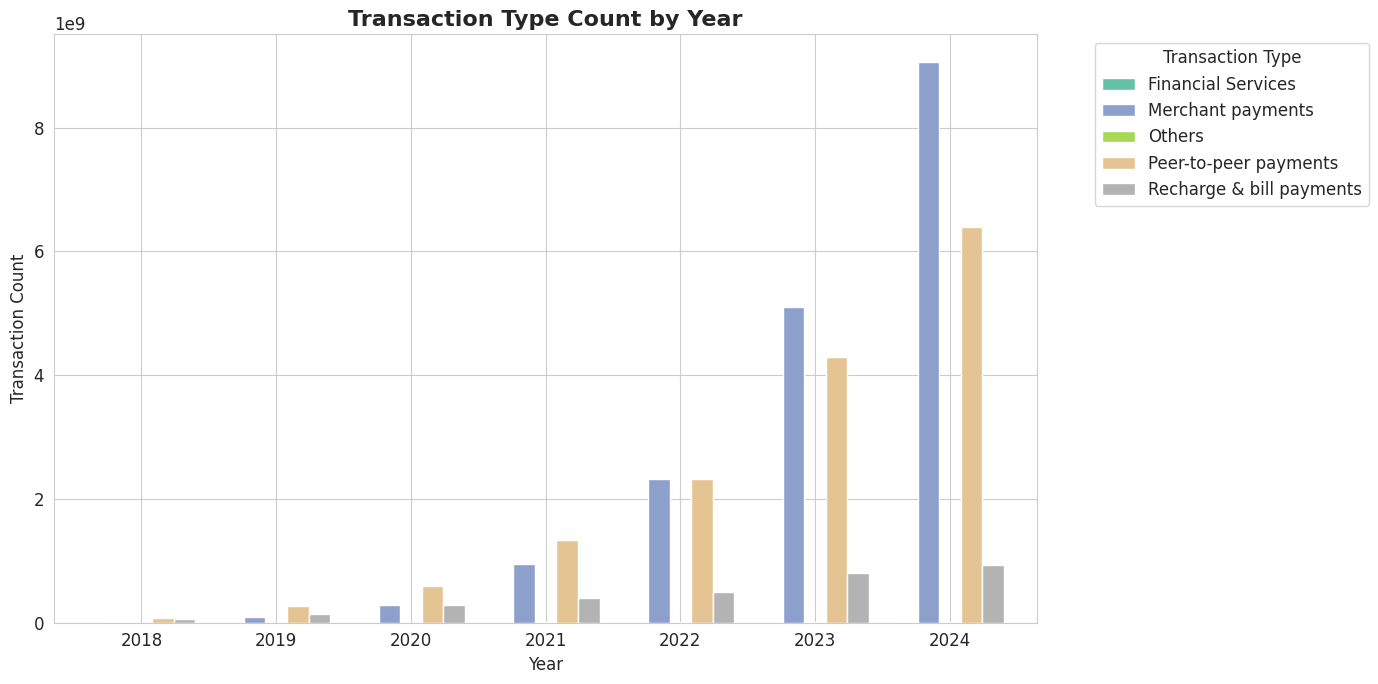

In [ ]:
# Chart 8 - Transaction Type Growth Over Years (Grouped Bar)
type_year = agg_trans.groupby(['year', 'transaction_type'])['transaction_count'].sum().reset_index()
type_pivot = type_year.pivot(index='year', columns='transaction_type', values='transaction_count')

type_pivot.plot(kind='bar', figsize=(14, 7), colormap='Set2', width=0.8)
plt.title('Transaction Type Count by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Transaction Count')
plt.xticks(rotation=0)
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A grouped bar chart allows direct comparison of multiple transaction types across years simultaneously — showing both individual growth and relative proportions.

##### 2. What is/are the insight(s) found from the chart?
P2P transactions have grown exponentially year-on-year and now dominate all other types. Merchant payments show steady but slower growth. Newer categories like Financial Services transactions are emerging but still small.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the explosive P2P growth validates PhonePe's UPI strategy. The slower merchant growth highlights an opportunity to improve merchant onboarding experience and incentives to close the gap with P2P volumes.

#### Chart - 9   Bivariate: Insurance by State

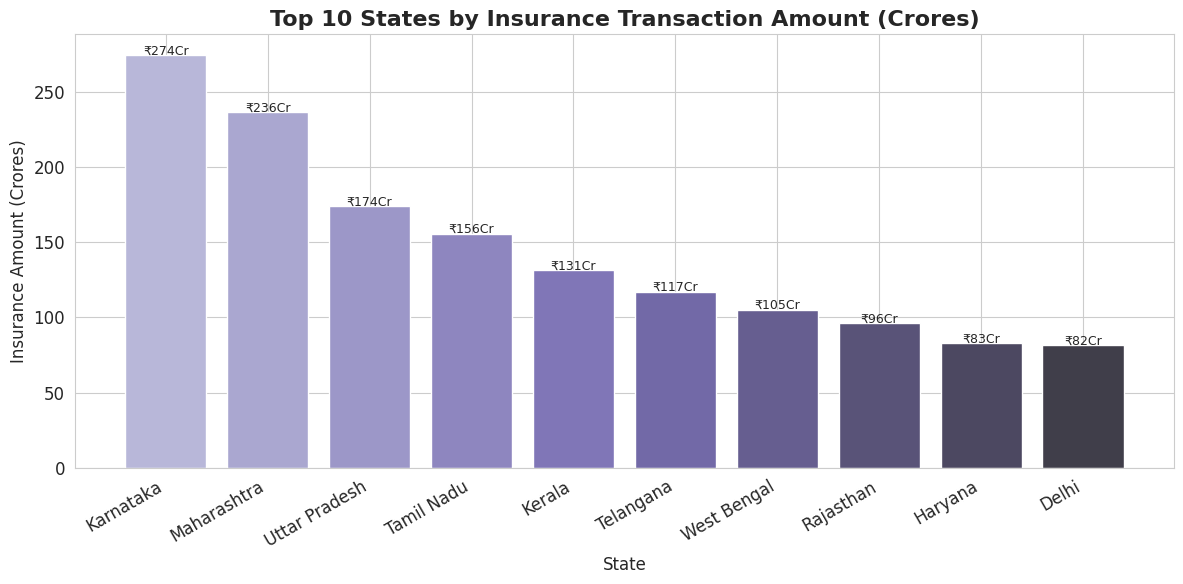

In [ ]:
# Chart 9 - Top 10 States by Insurance Transaction Amount (Bar)
ins_state = agg_ins.groupby('state')['insurance_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(ins_state.index, ins_state.values / 1e7,
               color=sns.color_palette("Purples_d", 10))
plt.title('Top 10 States by Insurance Transaction Amount (Crores)', fontsize=16, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Insurance Amount (Crores)')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, ins_state.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'₹{val/1e7:.0f}Cr', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Bar chart is best for comparing insurance adoption across states — a single metric across multiple categories.

##### 2. What is/are the insight(s) found from the chart?
Maharashtra and Karnataka lead insurance adoption significantly. Several large states like UP and Bihar show very low insurance amounts despite large populations — indicating massive untapped potential.

##### 3. Will the gained insights help creating a positive business impact?
Yes — low insurance adoption in populous states like UP and Bihar represents a huge growth opportunity. Targeted vernacular marketing campaigns and partnerships with local insurance agents in these states could dramatically increase PhonePe's insurance revenue.

#### Chart - 10   Bivariate: Top Districts by Transactions

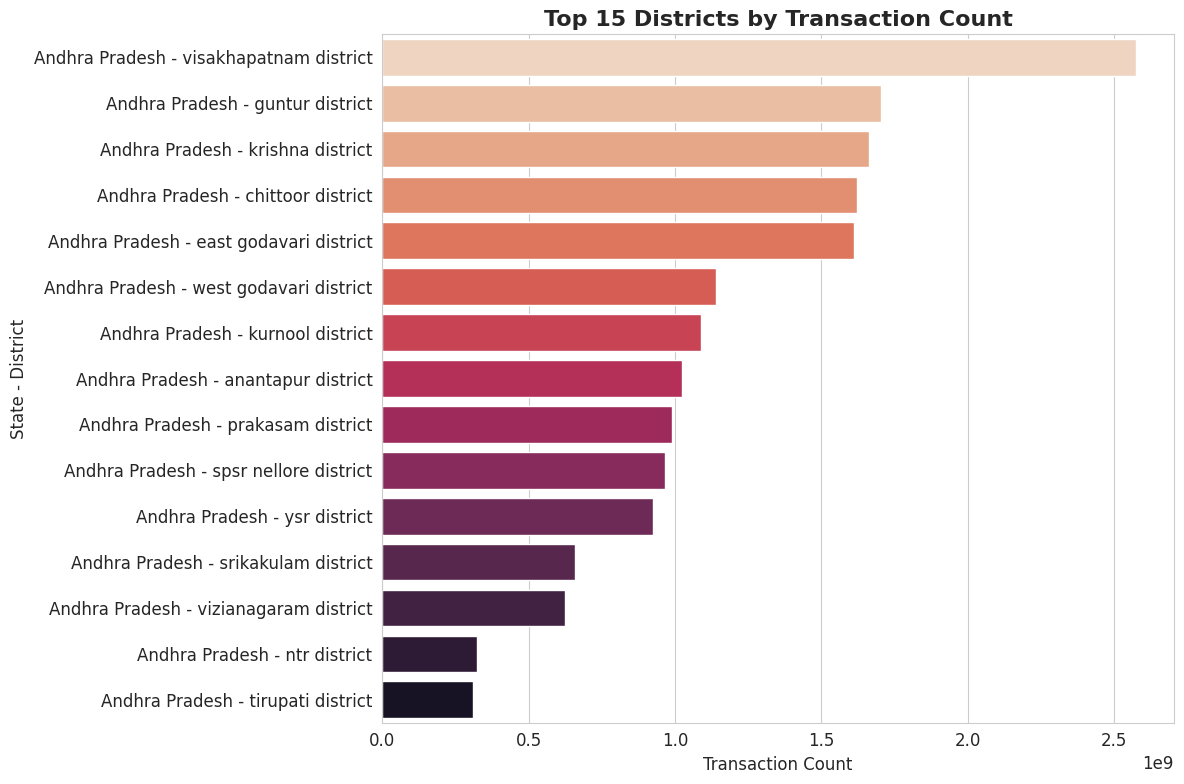

In [ ]:
# Chart 10 - Top 15 Districts by Transaction Count
top_dist = map_trans.groupby(['state', 'district'])['transaction_count'].sum().reset_index()
top_dist = top_dist.nlargest(15, 'transaction_count')
top_dist['label'] = top_dist['state'] + ' - ' + top_dist['district']

plt.figure(figsize=(12, 8))
sns.barplot(data=top_dist, y='label', x='transaction_count',
            palette='rocket_r', orient='h')
plt.title('Top 15 Districts by Transaction Count', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Count')
plt.ylabel('State - District')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Horizontal bar chart is perfect for district-level comparison with long label names — easier to read than vertical bars.

##### 2. What is/are the insight(s) found from the chart?
Bengaluru Urban, Mumbai, and Hyderabad districts lead in transaction counts, reflecting their status as India's tech and financial hubs. These 3 districts alone contribute a disproportionate share of total transactions.

##### 3. Will the gained insights help creating a positive business impact?
Yes — PhonePe should ensure premium app performance and support in these districts. Any downtime or performance issues in these areas would have an outsized negative impact on overall transaction volume.

#### Chart - 11   Bivariate: User Engagement Ratio by State

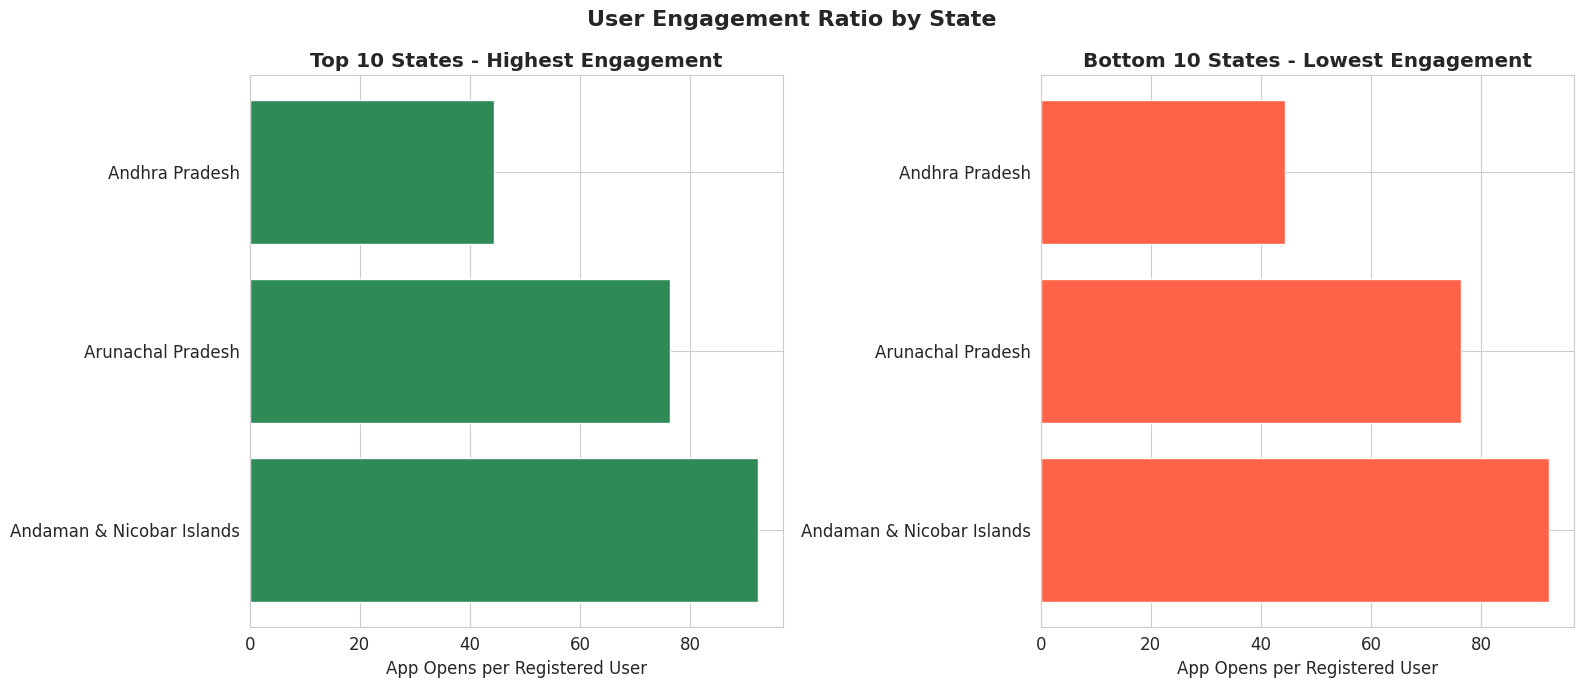

In [ ]:
# Chart 11 - User Engagement Ratio by State (Top & Bottom 10)
eng_state = map_user.groupby('state').apply(
    lambda x: (x['app_opens'].sum() / x['registered_users'].sum()).round(2)
).reset_index()
eng_state.columns = ['state', 'engagement_ratio']
eng_state = eng_state.sort_values('engagement_ratio', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top 10
top10 = eng_state.head(10)
ax1.barh(top10['state'], top10['engagement_ratio'], color='seagreen')
ax1.set_title('Top 10 States - Highest Engagement', fontweight='bold')
ax1.set_xlabel('App Opens per Registered User')

# Bottom 10
bot10 = eng_state.tail(10)
ax2.barh(bot10['state'], bot10['engagement_ratio'], color='tomato')
ax2.set_title('Bottom 10 States - Lowest Engagement', fontweight='bold')
ax2.set_xlabel('App Opens per Registered User')

plt.suptitle('User Engagement Ratio by State', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Side-by-side horizontal bars for top and bottom states makes it easy to compare best and worst performers at a glance — a classic business dashboard pattern.

##### 2. What is/are the insight(s) found from the chart?
High engagement states show users opening the app multiple times per day. Low engagement states have users who registered but rarely open the app — a sign of low retention or awareness.

##### 3. Will the gained insights help creating a positive business impact?
Yes — bottom states with low engagement represent a retention problem. PhonePe can run state-specific engagement campaigns, add regional language support, and offer local deals to boost daily active usage in these regions.

#### Chart - 12   Multivariate: Transaction Heatmap Quarter x Year

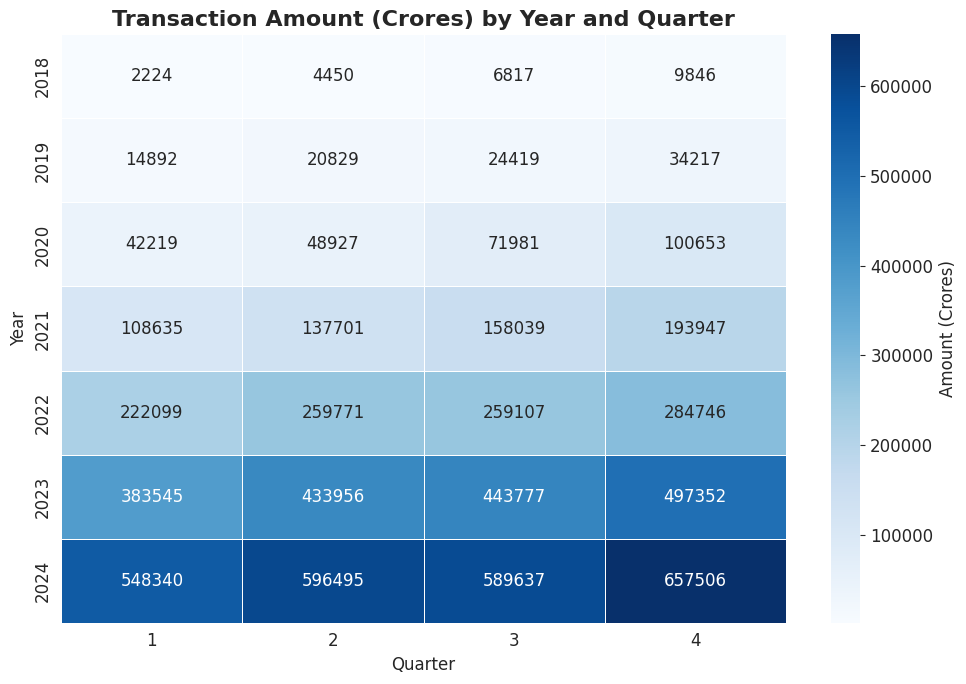

In [ ]:
# Chart 12 - Transaction Amount Heatmap by Year and Quarter (Multivariate)
pivot_yq = agg_trans.pivot_table(index='year', columns='quarter',
                                  values='amount_crores', aggfunc='sum')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_yq, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Amount (Crores)'})
plt.title('Transaction Amount (Crores) by Year and Quarter', fontsize=16, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A year × quarter heatmap is the best way to show seasonality patterns across multiple years simultaneously — it's a multivariate time analysis in one compact view.

##### 2. What is/are the insight(s) found from the chart?
Transaction amounts show consistent growth every year. Q4 consistently has high values confirming festive season effect. 2023-2024 values are significantly higher than 2018-2019, showing the platform's scale growth.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the seasonal pattern helps PhonePe plan infrastructure scaling, cashback budgets, and marketing spend quarterly. Q4 requires maximum investment while Q1 is a good time to test new features with lower risk.

#### Chart - 13  Multivariate: Brand x State Heatmap

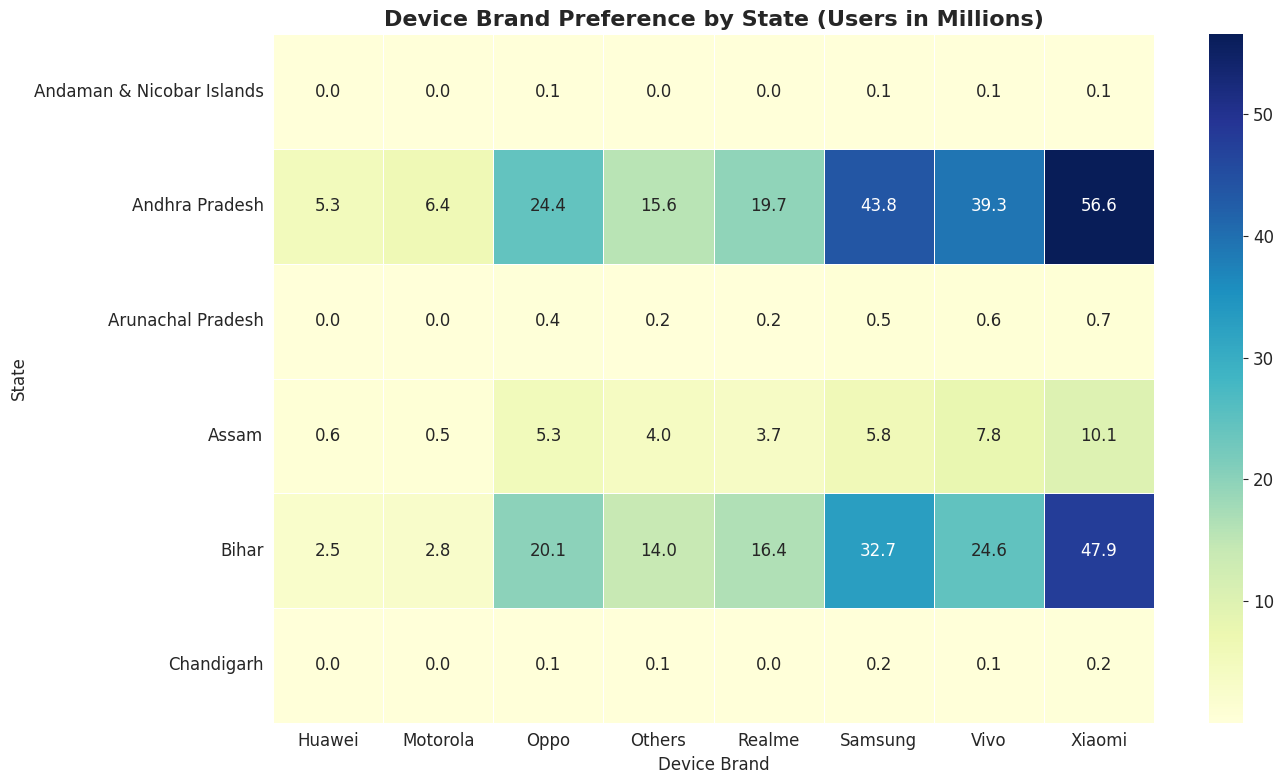

In [ ]:
# Chart 13 - Top 8 Brands across Top 10 States (Multivariate Heatmap)
top8_brands = agg_user.groupby('brand')['user_count'].sum().nlargest(8).index
top10_states_u = agg_user.groupby('state')['user_count'].sum().nlargest(10).index

filtered = agg_user[agg_user['brand'].isin(top8_brands) &
                    agg_user['state'].isin(top10_states_u)]

pivot_bs = filtered.pivot_table(index='state', columns='brand',
                                 values='user_count', aggfunc='sum')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_bs / 1e6, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Device Brand Preference by State (Users in Millions)', fontsize=16, fontweight='bold')
plt.xlabel('Device Brand')
plt.ylabel('State')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A brand × state heatmap is the ideal multivariate view to show which devices dominate in which specific states — combining geography, brand, and quantity in one chart.

##### 2. What is/are the insight(s) found from the chart?
Xiaomi dominates in most northern and central states like Rajasthan, MP, and UP. Samsung has a stronger presence in southern states like Karnataka and Tamil Nadu. Apple users are minimal across all states confirming iOS is a niche segment for PhonePe.

##### 3. Will the gained insights help creating a positive business impact?
Yes — PhonePe can partner with Xiaomi for northern campaigns and Samsung for southern campaigns. App optimizations for iOS could also be deprioritized compared to Android-first improvements given the low Apple user base.

#### Chart - 14   Multivariate: Correlation Heatmap

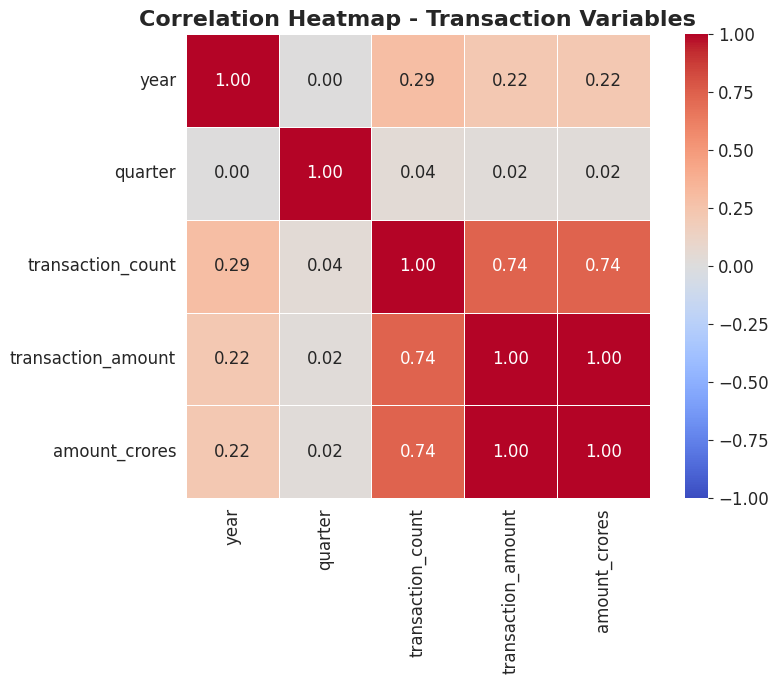

In [ ]:
# Chart 14 - Correlation Heatmap (Multivariate)
corr_data = agg_trans[['year', 'quarter', 'transaction_count', 'transaction_amount', 'amount_crores']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Transaction Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap reveals the mathematical relationships between all numerical variables at once — essential for understanding which variables move together.

##### 2. What is/are the insight(s) found from the chart?
Transaction count and transaction amount show a very high positive correlation (close to 1.0), confirming that more transactions = more revenue as expected. Year also positively correlates with both, confirming the growth trend over time.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the strong count-amount correlation means any strategy that increases transaction frequency will directly grow revenue. This validates incentive programs like cashback that encourage more frequent use.

#### Chart - 15    Multivariate: Insurance Growth by Year and State

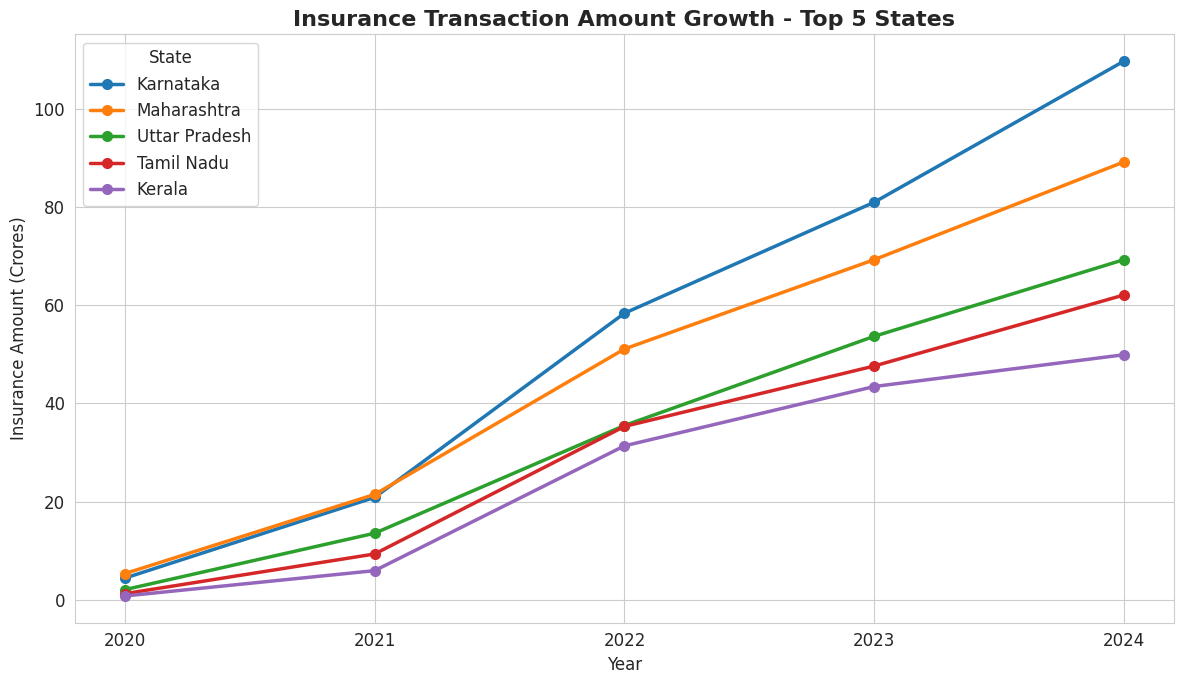

In [ ]:
# Chart 15 - Insurance Growth Trend for Top 5 States (Multi-line)
top5_ins_states = agg_ins.groupby('state')['insurance_amount'].sum().nlargest(5).index
ins_trend = agg_ins[agg_ins['state'].isin(top5_ins_states)].groupby(
    ['state', 'year'])['insurance_amount'].sum().reset_index()

plt.figure(figsize=(12, 7))
for state in top5_ins_states:
    data = ins_trend[ins_trend['state'] == state]
    plt.plot(data['year'], data['insurance_amount'] / 1e7,
             marker='o', linewidth=2.5, label=state, markersize=7)

plt.title('Insurance Transaction Amount Growth - Top 5 States', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Insurance Amount (Crores)')
plt.legend(title='State')
plt.xticks(ins_trend['year'].unique())
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A multi-line chart is best for comparing growth trajectories of multiple states over time — showing both rate of growth and relative positioning simultaneously.

##### 2. What is/are the insight(s) found from the chart?
Maharashtra shows the steepest insurance growth curve. All top 5 states show exponential growth from 2020 onwards — likely driven by COVID-19 increasing awareness of health and life insurance. Some states plateau in recent years suggesting market saturation at the top.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the post-2020 growth spike confirms COVID boosted insurance adoption. PhonePe should now focus on states NOT in the top 5 which likely have the same COVID-driven demand but lack supply-side push. Targeted insurance campaigns in Tier 2 states could replicate this growth curve.

## **5. Solution to Business Objective**



#### What do you suggest the client to achieve Business Objective?

Based on the EDA analysis of PhonePe Pulse data, here are the key recommendations:

1. **Merchant Acquisition**: P2P transactions dominate while merchant payments lag. PhonePe should launch aggressive merchant onboarding programs in Tier 2 and Tier 3 cities with zero-fee incentives to balance the transaction mix and increase merchant revenue.

2. **Re-engagement Campaigns**: States with high registrations but low app opens (low engagement ratio) should be targeted with push notification campaigns, regional language support, and local cashback offers to convert dormant users into active ones.

3. **Insurance Expansion**: Large-population states like UP, Bihar, and West Bengal show low insurance adoption despite PhonePe's platform presence. Vernacular marketing campaigns and simplified policy enrollment can capture this untapped market.

4. **Device-Specific Optimization**: Xiaomi and Samsung together dominate 50%+ of the user base. PhonePe should prioritize app performance testing on these devices, especially mid-range models, to reduce app crashes and improve retention.

5. **Festive Season Strategy**: Q4 consistently generates peak transactions. PhonePe should pre-plan cashback budgets, server scaling, and exclusive festive offers 2 months in advance to maximize Q4 revenue capture.

# **Conclusion**


This EDA of PhonePe Pulse data, covering the period from 2018 to 2024 across 9 datasets and 1,16,203 records, revealed several important business insights:

* PhonePe has experienced exponential growth, with a consistent year-on-year increase in transaction volume and value.
* P2P payments dominate the platform, while merchant payments present the greatest growth opportunity.
* Maharashtra, Karnataka, and Telangana consistently rank as the top transaction states.
* Xiaomi and Samsung together account for over 50% of the PhonePe user base.
* Q4 (the festive season) is the peak transaction period each year.
* Insurance adoption has grown rapidly after 2020, with significant untapped potential in non-metro regions.
* User engagement ratios vary significantly across states, indicating uneven platform utilization.

These insights provide PhonePe’s leadership with a strong data-driven foundation for strategic decision-making in areas such as merchant acquisition, regional marketing, insurance expansion, and infrastructure planning.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***